In [1]:
import os
os.getcwd()

'/Users/lenovo1/Documents'

In [2]:
!pip show opencv-python numpy tqdm

Name: numpy
Version: 1.23.5
Summary: NumPy is the fundamental package for array computing with Python.
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: None
License: BSD
Location: /Users/lenovo1/opt/anaconda3/lib/python3.8/site-packages
Requires: 
Required-by: tensorflow, tensorboard, opt-einsum, Keras-Preprocessing, h5py, xgboost, tifffile, tables, statsmodels, shap, seaborn, scipy, scikit-learn, scikit-image, PyWavelets, pyerfa, pyarrow, patsy, pandas, opencv-python-headless, numexpr, numba, mkl-random, mkl-fft, matplotlib, lightgbm, imageio, folium, Bottleneck, bokeh, bkcharts, astropy
---
Name: tqdm
Version: 4.59.0
Summary: Fast, Extensible Progress Meter
Home-page: https://github.com/tqdm/tqdm
Author: None
Author-email: None
License: MPLv2.0, MIT Licences
Location: /Users/lenovo1/opt/anaconda3/lib/python3.8/site-packages
Requires: 
Required-by: shap, nltk, conda-build


In [3]:
!pip install opencv-python-headless==4.8.1.78 -q

In [4]:
import cv2
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.8.1


In [5]:
import numpy as np
import tqdm

print("Numpy version:", np.__version__)
print("r\tqdm version:", tqdm.__version__)

Numpy version: 1.23.5
r	qdm version: 4.59.0


In [6]:
import os
print(os.getcwd())

/Users/lenovo1/Documents


In [1]:
import os
import cv2
import numpy as np
from pathlib import Path
import random
import json
from datetime import datetime
from tqdm.notebook import tqdm  # notebook version for better progress bars

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

CONFIG = {
    "input_dir": "AI_Document_Classifier",
    "output_dir": "AI_Document_Classifier_Augmented",
    "classes": {
        "aadhar":    "Aadhar_Card",
        "pan":       "Pan_Card",
        "marksheet": "Marksheet",
    },
    "target_count": 500,
    "image_size": (224, 224),
    "extensions": [".jpg", ".jpeg", ".png", ".bmp", ".webp"],
    "seed": 42,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# ─────────────────────────────────────────────
# AUGMENTATION FUNCTIONS
# ─────────────────────────────────────────────

def rotate_image(img):
    angle = random.uniform(-20, 20)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def flip_image(img):
    return cv2.flip(img, 1)

def adjust_brightness(img):
    factor = random.uniform(0.6, 1.4)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def adjust_contrast(img):
    factor = random.uniform(0.7, 1.3)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=factor * 2, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

def add_gaussian_noise(img):
    std = random.uniform(5, 25)
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def zoom_image(img):
    zoom = random.uniform(0.85, 1.15)
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom), int(w * zoom)
    resized = cv2.resize(img, (new_w, new_h))
    if zoom > 1.0:
        start_y = (new_h - h) // 2
        start_x = (new_w - w) // 2
        return resized[start_y:start_y + h, start_x:start_x + w]
    else:
        pad_y = (h - new_h) // 2
        pad_x = (w - new_w) // 2
        return cv2.copyMakeBorder(resized, pad_y, h - new_h - pad_y,
                                  pad_x, w - new_w - pad_x, cv2.BORDER_REFLECT)

def shear_image(img):
    shear = random.uniform(-0.15, 0.15)
    h, w = img.shape[:2]
    M = np.array([[1, shear, 0], [0, 1, 0]], dtype=np.float32)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def blur_image(img):
    k = random.choice([1, 3, 5])
    return img if k == 1 else cv2.GaussianBlur(img, (k, k), 0)

def adjust_hue_saturation(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + random.uniform(-10, 10)) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.7, 1.3), 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def perspective_transform(img):
    h, w = img.shape[:2]
    d = 0.05
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([
        [random.uniform(0, d * w), random.uniform(0, d * h)],
        [random.uniform((1 - d) * w, w), random.uniform(0, d * h)],
        [random.uniform((1 - d) * w, w), random.uniform((1 - d) * h, h)],
        [random.uniform(0, d * w), random.uniform((1 - d) * h, h)],
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def apply_random_augmentation(img):
    augmentations = [
        rotate_image, flip_image, adjust_brightness, adjust_contrast,
        add_gaussian_noise, zoom_image, shear_image, blur_image,
        adjust_hue_saturation, perspective_transform,
    ]
    chosen = random.sample(augmentations, k=random.randint(2, 4))
    result = img.copy()
    for fn in chosen:
        result = fn(result)
    return result


# ─────────────────────────────────────────────
# CORE PIPELINE
# ─────────────────────────────────────────────

def load_images_from_folder(folder, extensions):
    images = []
    paths = []
    for ext in extensions:
        paths.extend(folder.glob(f"*{ext}"))
        paths.extend(folder.glob(f"*{ext.upper()}"))
    for p in sorted(set(paths)):
        img = cv2.imread(str(p))
        if img is not None:
            images.append((p.name, img))
        else:
            print(f"  ⚠  Could not read: {p.name}")
    return images

def augment_class(class_name, input_folder, output_folder, target_count, image_size, extensions):
    output_folder.mkdir(parents=True, exist_ok=True)

    print(f"\n{'─'*50}")
    print(f"  Class : {class_name}")
    print(f"{'─'*50}")

    images = load_images_from_folder(input_folder, extensions)
    if not images:
        print(f"  ✗ No images found. Skipping.")
        return 0, 0

    original_count = len(images)
    print(f"  Found {original_count} original images.")

    # Copy originals
    saved = 0
    for fname, img in images:
        resized = cv2.resize(img, image_size)
        cv2.imwrite(str(output_folder / fname), resized)
        saved += 1
    print(f"  ✔ Copied {saved} originals (resized to {image_size[0]}×{image_size[1]}).")

    # Generate augmented images
    needed = max(0, target_count - saved)
    print(f"  Generating {needed} augmented images...")

    aug_index = 0
    for _ in tqdm(range(needed), desc=f"  {class_name}"):
        src_name, src_img = random.choice(images)
        stem = Path(src_name).stem
        aug_img = apply_random_augmentation(src_img)
        aug_img = cv2.resize(aug_img, image_size)
        out_name = f"aug_{stem}_{aug_index:04d}.jpg"
        cv2.imwrite(str(output_folder / out_name), aug_img,
                    [cv2.IMWRITE_JPEG_QUALITY, 92])
        saved += 1
        aug_index += 1

    augmented_count = saved - original_count
    print(f"  ✔ Done! {original_count} original + {augmented_count} augmented = {saved} total")
    return original_count, saved


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

print("═" * 50)
print("  AI Document Classifier — Data Augmentation")
print("  MPOnline AIML Internship Project")
print("═" * 50)

input_root  = Path(CONFIG["input_dir"])
output_root = Path(CONFIG["output_dir"])

if not input_root.exists():
    print(f"\n✗ ERROR: '{input_root}' folder not found!")
    print(f"  Current directory: {os.getcwd()}")
    print("  Make sure 'AI_Document_Classifier' is in the same folder as this notebook.")
else:
    output_root.mkdir(parents=True, exist_ok=True)
    stats = {}

    for key, class_folder_name in CONFIG["classes"].items():
        input_folder  = input_root  / class_folder_name
        output_folder = output_root / class_folder_name

        if not input_folder.exists():
            print(f"\n⚠  Folder not found, skipping: {input_folder}")
            continue

        orig, final = augment_class(
            class_name    = class_folder_name,
            input_folder  = input_folder,
            output_folder = output_folder,
            target_count  = CONFIG["target_count"],
            image_size    = CONFIG["image_size"],
            extensions    = CONFIG["extensions"],
        )
        stats[class_folder_name] = {"original": orig, "augmented": final - orig, "final": final}

    # Summary
    print("\n" + "═" * 50)
    print(f"  {'Class':<18} {'Original':>9} {'Augmented':>10} {'Total':>7}")
    print("  " + "─" * 46)
    for cls, s in stats.items():
        print(f"  {cls:<18} {s['original']:>9} {s['augmented']:>10} {s['final']:>7}")
    print("  " + "─" * 46)
    total = sum(s["final"] for s in stats.values())
    print(f"  {'TOTAL':<18} {sum(s['original'] for s in stats.values()):>9} "
          f"{sum(s['augmented'] for s in stats.values()):>10} {total:>7}")
    print("═" * 50)
    print(f"\n✔ Augmented dataset saved to: '{output_root}/'")
    print("  Next step: Use this folder for model training.")

══════════════════════════════════════════════════
  AI Document Classifier — Data Augmentation
  MPOnline AIML Internship Project
══════════════════════════════════════════════════

──────────────────────────────────────────────────
  Class : Aadhar_Card
──────────────────────────────────────────────────
  Found 59 original images.
  ✔ Copied 59 originals (resized to 224×224).
  Generating 441 augmented images...


  Aadhar_Card:   0%|          | 0/441 [00:00<?, ?it/s]

  ✔ Done! 59 original + 441 augmented = 500 total

──────────────────────────────────────────────────
  Class : Pan_Card
──────────────────────────────────────────────────
  Found 68 original images.
  ✔ Copied 68 originals (resized to 224×224).
  Generating 432 augmented images...


  Pan_Card:   0%|          | 0/432 [00:00<?, ?it/s]

  ✔ Done! 68 original + 432 augmented = 500 total

──────────────────────────────────────────────────
  Class : Marksheet
──────────────────────────────────────────────────
  Found 73 original images.
  ✔ Copied 73 originals (resized to 224×224).
  Generating 427 augmented images...


  Marksheet:   0%|          | 0/427 [00:00<?, ?it/s]

  ✔ Done! 73 original + 427 augmented = 500 total

══════════════════════════════════════════════════
  Class               Original  Augmented   Total
  ──────────────────────────────────────────────
  Aadhar_Card               59        441     500
  Pan_Card                  68        432     500
  Marksheet                 73        427     500
  ──────────────────────────────────────────────
  TOTAL                    200       1300    1500
══════════════════════════════════════════════════

✔ Augmented dataset saved to: 'AI_Document_Classifier_Augmented/'
  Next step: Use this folder for model training.


In [7]:
from pathlib import Path

output_root = Path("AI_Document_Classifier_Augmented")

print("📁 Augmented Dataset Summary")
print("═" * 40)

total = 0
for class_folder in output_root.iterdir():
    if class_folder.is_dir():
        count = len(list(class_folder.glob("*")))
        total += count
        print(f"  {class_folder.name:<18} → {count} images")

print("═" * 40)
print(f"  {'TOTAL':<18} → {total} images")

📁 Augmented Dataset Summary
════════════════════════════════════════
  Aadhar_Card        → 500 images
  Pan_Card           → 500 images
  Marksheet          → 500 images
════════════════════════════════════════
  TOTAL              → 1500 images


In [11]:
import numpy as np
import tensorflow as tf

print("Numpy version:", np.__version__)
print("TensorFlow version:", tf.__version__)

Numpy version: 1.23.5
TensorFlow version: 2.6.0


TensorFlow version: 2.6.0
Using CPU for training

══════════════════════════════════════════════════
  AI Document Classifier — Model Training
  Framework : TensorFlow/Keras
  Model     : MobileNetV2 (Transfer Learning)
  Device    : CPU
══════════════════════════════════════════════════

📂 STEP 1: Loading Dataset...
Found 1200 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

  Classes found     : {'Aadhar_Card': 0, 'Marksheet': 1, 'Pan_Card': 2}
  Training images   : 1200
  Validation images : 300
  ✔ Class mapping saved.

🧠 STEP 2: Building MobileNetV2 Model...
  Total layers     : 160
  Trainable layers : 6
  Frozen layers    : 154

⚙️  STEP 3: Setting up Callbacks...
  ✔ EarlyStopping     — stops if no improvement for 5 epochs
  ✔ ModelCheckpoint   — saves best model automatically
  ✔ ReduceLROnPlateau — reduces learning rate when stuck

🚀 STEP 4: Training Started...
  This will take 15–30 mins on CPU. Please wait...

Epoch 1/20
75/75 [======================

/Users/lenovo1/.local/lib/python3.8/site-packages/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


Epoch 2/20
75/75 [==============================] - 34s 454ms/step - loss: 0.4692 - accuracy: 0.8350 - val_loss: 0.2668 - val_accuracy: 0.9567

Epoch 00002: val_accuracy improved from 0.91333 to 0.95667, saving model to saved_model/best_model.h5
Epoch 3/20
75/75 [==============================] - 30s 396ms/step - loss: 0.3162 - accuracy: 0.9000 - val_loss: 0.1799 - val_accuracy: 0.9567

Epoch 00003: val_accuracy did not improve from 0.95667
Epoch 4/20
75/75 [==============================] - 30s 397ms/step - loss: 0.2250 - accuracy: 0.9383 - val_loss: 0.1474 - val_accuracy: 0.9600

Epoch 00004: val_accuracy improved from 0.95667 to 0.96000, saving model to saved_model/best_model.h5
Epoch 5/20
75/75 [==============================] - 30s 395ms/step - loss: 0.1776 - accuracy: 0.9475 - val_loss: 0.1267 - val_accuracy: 0.9700

Epoch 00005: val_accuracy improved from 0.96000 to 0.97000, saving model to saved_model/best_model.h5
Epoch 6/20
75/75 [==============================] - 30s 402ms/s

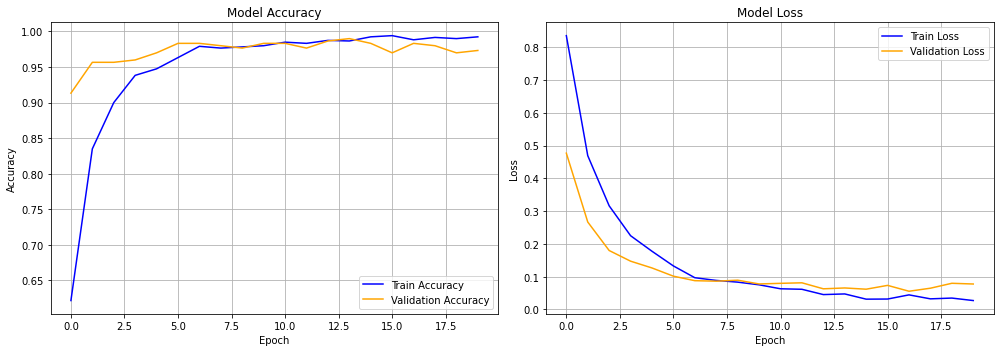

  ✔ Graphs saved.

💾 STEP 7: Saving Final Model...
  ✔ Final model saved  → 'saved_model/final_model.h5'
  ✔ Best model saved   → 'saved_model/best_model.h5'
  ✔ Model info saved   → 'saved_model/model_info.json'

══════════════════════════════════════════════════
  🎉 ALL DONE! Model Training Complete.
  Final Validation Accuracy : 97.33%
══════════════════════════════════════════════════


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Using CPU for training\n")

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

CONFIG = {
    "dataset_dir":      "AI_Document_Classifier_Augmented",
    "model_save_dir":   "saved_model",
    "image_size":       (224, 224),
    "batch_size":       16,
    "epochs":           20,
    "learning_rate":    0.0001,
    "validation_split": 0.2,
    "classes":          ["Aadhar_Card", "Pan_Card", "Marksheet"],
    "seed":             42,
}

Path(CONFIG["model_save_dir"]).mkdir(parents=True, exist_ok=True)

print("═" * 50)
print("  AI Document Classifier — Model Training")
print("  Framework : TensorFlow/Keras")
print("  Model     : MobileNetV2 (Transfer Learning)")
print("  Device    : CPU")
print("═" * 50)


# ─────────────────────────────────────────────
# STEP 1 — DATA PREPARATION
# ─────────────────────────────────────────────

print("\n📂 STEP 1: Loading Dataset...")

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
)

train_generator = train_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="training",
    seed=CONFIG["seed"],
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="validation",
    seed=CONFIG["seed"],
    shuffle=False,
)

class_indices = train_generator.class_indices
class_names   = {v: k for k, v in class_indices.items()}

print(f"\n  Classes found     : {class_indices}")
print(f"  Training images   : {train_generator.samples}")
print(f"  Validation images : {val_generator.samples}")

with open(f"{CONFIG['model_save_dir']}/class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=2)
print(f"  ✔ Class mapping saved.")


# ─────────────────────────────────────────────
# STEP 2 — BUILD MODEL
# ─────────────────────────────────────────────

print("\n🧠 STEP 2: Building MobileNetV2 Model...")

base_model = MobileNetV2(
    input_shape=(*CONFIG["image_size"], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(128, activation="relu")(x)
x      = Dropout(0.3)(x)
x      = Dense(64, activation="relu")(x)
x      = Dropout(0.2)(x)
output = Dense(len(CONFIG["classes"]), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=CONFIG["learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"  Total layers     : {len(model.layers)}")
print(f"  Trainable layers : {len([l for l in model.layers if l.trainable])}")
print(f"  Frozen layers    : {len([l for l in model.layers if not l.trainable])}")


# ─────────────────────────────────────────────
# STEP 3 — CALLBACKS
# ─────────────────────────────────────────────

print("\n⚙️  STEP 3: Setting up Callbacks...")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=f"{CONFIG['model_save_dir']}/best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("  ✔ EarlyStopping     — stops if no improvement for 5 epochs")
print("  ✔ ModelCheckpoint   — saves best model automatically")
print("  ✔ ReduceLROnPlateau — reduces learning rate when stuck")


# ─────────────────────────────────────────────
# STEP 4 — TRAIN MODEL
# ─────────────────────────────────────────────

print("\n🚀 STEP 4: Training Started...")
print("  This will take 15–30 mins on CPU. Please wait...\n")

history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1,
)

print("\n  ✔ Training Complete!")


# ─────────────────────────────────────────────
# STEP 5 — EVALUATE MODEL
# ─────────────────────────────────────────────

print("\n📊 STEP 5: Evaluating Model...")

val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"\n  Validation Loss     : {val_loss:.4f}")
print(f"  Validation Accuracy : {val_accuracy * 100:.2f}%")


# ─────────────────────────────────────────────
# STEP 6 — PLOT TRAINING GRAPHS
# ─────────────────────────────────────────────

print("\n📈 STEP 6: Plotting Training Graphs...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['model_save_dir']}/training_graphs.png", dpi=150)
plt.show()
print("  ✔ Graphs saved.")


# ─────────────────────────────────────────────
# STEP 7 — SAVE FINAL MODEL
# ─────────────────────────────────────────────

print("\n💾 STEP 7: Saving Final Model...")

model.save(f"{CONFIG['model_save_dir']}/final_model.h5")

model_info = {
    "model_name":     "MobileNetV2",
    "input_size":     CONFIG["image_size"],
    "classes":        class_indices,
    "total_params":   model.count_params(),
    "val_accuracy":   round(val_accuracy * 100, 2),
    "val_loss":       round(val_loss, 4),
    "epochs_trained": len(history.history["loss"]),
    "framework":      "TensorFlow/Keras",
}

with open(f"{CONFIG['model_save_dir']}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"  ✔ Final model saved  → 'saved_model/final_model.h5'")
print(f"  ✔ Best model saved   → 'saved_model/best_model.h5'")
print(f"  ✔ Model info saved   → 'saved_model/model_info.json'")

print("\n" + "═" * 50)
print("  🎉 ALL DONE! Model Training Complete.")
print(f"  Final Validation Accuracy : {val_accuracy * 100:.2f}%")
print("═" * 50)

In [13]:
import json

with open("saved_model/model_info.json", "r") as f:
    info = json.load(f)

print("═" * 50)
print("  📊 Model Training Results")
print("═" * 50)
print(f"  Model        : {info['model_name']}")
print(f"  Val Accuracy : {info['val_accuracy']}%")
print(f"  Val Loss     : {info['val_loss']}")
print(f"  Epochs Trained : {info['epochs_trained']}")
print(f"  Total Params : {info['total_params']:,}")
print(f"  Classes      : {list(info['classes'].keys())}")
print("═" * 50)

══════════════════════════════════════════════════
  📊 Model Training Results
══════════════════════════════════════════════════
  Model        : MobileNetV2
  Val Accuracy : 97.33%
  Val Loss     : 0.0778
  Epochs Trained : 20
  Total Params : 2,430,403
  Classes      : ['Aadhar_Card', 'Marksheet', 'Pan_Card']
══════════════════════════════════════════════════


TensorFlow version: 2.6.0
Training ResNet50 Model...

══════════════════════════════════════════════════
  AI Document Classifier — ResNet50 Training
  Framework : TensorFlow/Keras
  Model     : ResNet50 (Transfer Learning)
  Device    : CPU
══════════════════════════════════════════════════

📂 STEP 1: Loading Dataset...
Found 1200 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

  Classes found     : {'Aadhar_Card': 0, 'Marksheet': 1, 'Pan_Card': 2}
  Training images   : 1200
  Validation images : 300
  ✔ Class mapping saved.

🧠 STEP 2: Building ResNet50 Model...
94781440/94765736 [==============================] - 15s 0us/step
  Total layers     : 181
  Trainable layers : 6
  Frozen layers    : 175

⚙️  STEP 3: Setting up Callbacks...
  ✔ EarlyStopping     — stops if no improvement for 5 epochs
  ✔ ModelCheckpoint   — saves best model automatically
  ✔ ReduceLROnPlateau — reduces learning rate when stuck

🚀 STEP 4: Training Started...
  ResNet50 is larger than

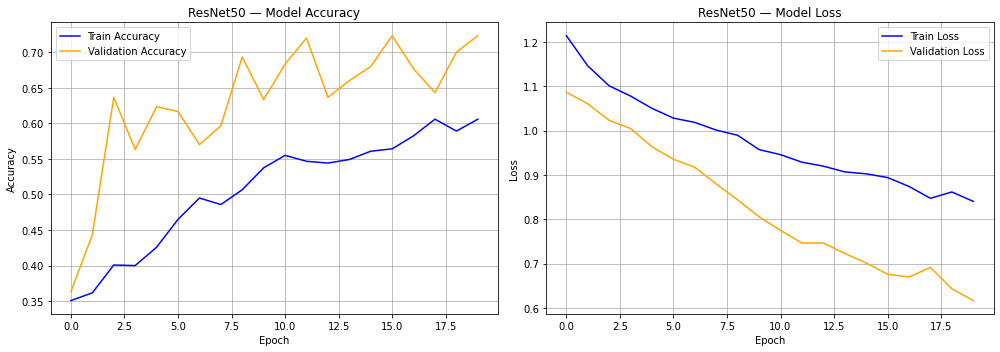

  ✔ Graphs saved.

💾 STEP 7: Saving Final Model...
  ✔ Final model saved  → 'saved_model_resnet/final_model_resnet.h5'
  ✔ Best model saved   → 'saved_model_resnet/best_model_resnet.h5'
  ✔ Model info saved   → 'saved_model_resnet/model_info.json'

══════════════════════════════════════════════════
  🎉 ResNet50 Training Complete!
  Final Validation Accuracy : 72.33%
══════════════════════════════════════════════════

📊 STEP 8: Comparing Both Models...

═══════════════════════════════════════════════════════
  Metric                    MobileNetV2       ResNet50
  ───────────────────────────────────────────────────
  Val Accuracy                    96.0%         72.33%
  Val Loss                       0.0972         0.6165
  Epochs Trained                     20             20
  Total Params                2,430,403     24,145,539
═══════════════════════════════════════════════════════

  🏆 Best Model for FastAPI : MobileNetV2
  📁 Model Path             : saved_model/best_model.h5

  Us

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Training ResNet50 Model...\n")

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

CONFIG = {
    "dataset_dir":      "AI_Document_Classifier_Augmented",
    "model_save_dir":   "saved_model_resnet",
    "image_size":       (224, 224),
    "batch_size":       16,
    "epochs":           20,
    "learning_rate":    0.0001,
    "validation_split": 0.2,
    "classes":          ["Aadhar_Card", "Pan_Card", "Marksheet"],
    "seed":             42,
}

Path(CONFIG["model_save_dir"]).mkdir(parents=True, exist_ok=True)

print("═" * 50)
print("  AI Document Classifier — ResNet50 Training")
print("  Framework : TensorFlow/Keras")
print("  Model     : ResNet50 (Transfer Learning)")
print("  Device    : CPU")
print("═" * 50)


# ─────────────────────────────────────────────
# STEP 1 — DATA PREPARATION
# ─────────────────────────────────────────────

print("\n📂 STEP 1: Loading Dataset...")

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
)

train_generator = train_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="training",
    seed=CONFIG["seed"],
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="validation",
    seed=CONFIG["seed"],
    shuffle=False,
)

class_indices = train_generator.class_indices
class_names   = {v: k for k, v in class_indices.items()}

print(f"\n  Classes found     : {class_indices}")
print(f"  Training images   : {train_generator.samples}")
print(f"  Validation images : {val_generator.samples}")

with open(f"{CONFIG['model_save_dir']}/class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=2)
print(f"  ✔ Class mapping saved.")


# ─────────────────────────────────────────────
# STEP 2 — BUILD RESNET50 MODEL
# ─────────────────────────────────────────────

print("\n🧠 STEP 2: Building ResNet50 Model...")

base_model = ResNet50(
    input_shape=(*CONFIG["image_size"], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation="relu")(x)
x      = Dropout(0.4)(x)
x      = Dense(128, activation="relu")(x)
x      = Dropout(0.3)(x)
output = Dense(len(CONFIG["classes"]), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=CONFIG["learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"  Total layers     : {len(model.layers)}")
print(f"  Trainable layers : {len([l for l in model.layers if l.trainable])}")
print(f"  Frozen layers    : {len([l for l in model.layers if not l.trainable])}")


# ─────────────────────────────────────────────
# STEP 3 — CALLBACKS
# ─────────────────────────────────────────────

print("\n⚙️  STEP 3: Setting up Callbacks...")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=f"{CONFIG['model_save_dir']}/best_model_resnet.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("  ✔ EarlyStopping     — stops if no improvement for 5 epochs")
print("  ✔ ModelCheckpoint   — saves best model automatically")
print("  ✔ ReduceLROnPlateau — reduces learning rate when stuck")


# ─────────────────────────────────────────────
# STEP 4 — TRAIN MODEL
# ─────────────────────────────────────────────

print("\n🚀 STEP 4: Training Started...")
print("  ResNet50 is larger than MobileNetV2.")
print("  This may take 30–50 mins on CPU. Please wait...\n")

history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1,
)

print("\n  ✔ Training Complete!")


# ─────────────────────────────────────────────
# STEP 5 — EVALUATE MODEL
# ─────────────────────────────────────────────

print("\n📊 STEP 5: Evaluating Model...")

val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"\n  Validation Loss     : {val_loss:.4f}")
print(f"  Validation Accuracy : {val_accuracy * 100:.2f}%")


# ─────────────────────────────────────────────
# STEP 6 — PLOT TRAINING GRAPHS
# ─────────────────────────────────────────────

print("\n📈 STEP 6: Plotting Training Graphs...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[0].set_title("ResNet50 — Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[1].set_title("ResNet50 — Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['model_save_dir']}/resnet_training_graphs.png", dpi=150)
plt.show()
print("  ✔ Graphs saved.")


# ─────────────────────────────────────────────
# STEP 7 — SAVE FINAL MODEL
# ─────────────────────────────────────────────

print("\n💾 STEP 7: Saving Final Model...")

model.save(f"{CONFIG['model_save_dir']}/final_model_resnet.h5")

model_info = {
    "model_name":     "ResNet50",
    "input_size":     CONFIG["image_size"],
    "classes":        class_indices,
    "total_params":   model.count_params(),
    "val_accuracy":   round(val_accuracy * 100, 2),
    "val_loss":       round(val_loss, 4),
    "epochs_trained": len(history.history["loss"]),
    "framework":      "TensorFlow/Keras",
}

with open(f"{CONFIG['model_save_dir']}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"  ✔ Final model saved  → 'saved_model_resnet/final_model_resnet.h5'")
print(f"  ✔ Best model saved   → 'saved_model_resnet/best_model_resnet.h5'")
print(f"  ✔ Model info saved   → 'saved_model_resnet/model_info.json'")

print("\n" + "═" * 50)
print("  🎉 ResNet50 Training Complete!")
print(f"  Final Validation Accuracy : {val_accuracy * 100:.2f}%")
print("═" * 50)


# ─────────────────────────────────────────────
# STEP 8 — COMPARE BOTH MODELS
# ─────────────────────────────────────────────

print("\n📊 STEP 8: Comparing Both Models...")

# Load MobileNetV2 results
with open("saved_model/model_info.json", "r") as f:
    mobilenet_info = json.load(f)

print("\n" + "═" * 55)
print(f"  {'Metric':<22} {'MobileNetV2':>14} {'ResNet50':>14}")
print("  " + "─" * 51)
print(f"  {'Val Accuracy':<22} {str(mobilenet_info['val_accuracy'])+'%':>14} {str(round(val_accuracy*100,2))+'%':>14}")
print(f"  {'Val Loss':<22} {mobilenet_info['val_loss']:>14} {round(val_loss,4):>14}")
print(f"  {'Epochs Trained':<22} {mobilenet_info['epochs_trained']:>14} {len(history.history['loss']):>14}")
print(f"  {'Total Params':<22} {mobilenet_info['total_params']:>14,} {model.count_params():>14,}")
print("═" * 55)

# Pick winner
if val_accuracy * 100 >= mobilenet_info["val_accuracy"]:
    winner = "ResNet50"
    winner_path = "saved_model_resnet/best_model_resnet.h5"
else:
    winner = "MobileNetV2"
    winner_path = "saved_model/best_model.h5"

print(f"\n  🏆 Best Model for FastAPI : {winner}")
print(f"  📁 Model Path             : {winner_path}")
print(f"\n  Use '{winner}' for your FastAPI backend!")

TensorFlow version: 2.6.0
Training VGG16 Model...

══════════════════════════════════════════════════
  AI Document Classifier — VGG16 Training
  Framework : TensorFlow/Keras
  Model     : VGG16 (Transfer Learning)
  Device    : CPU
══════════════════════════════════════════════════

📂 STEP 1: Loading Dataset...
Found 1200 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

  Classes found     : {'Aadhar_Card': 0, 'Marksheet': 1, 'Pan_Card': 2}
  Training images   : 1200
  Validation images : 300
  ✔ Class mapping saved.

🧠 STEP 2: Building VGG16 Model...
58900480/58889256 [==============================] - 10s 0us/step
  Total layers     : 25
  Trainable layers : 6
  Frozen layers    : 19

⚙️  STEP 3: Setting up Callbacks...
  ✔ EarlyStopping     — stops if no improvement for 5 epochs
  ✔ ModelCheckpoint   — saves best model automatically
  ✔ ReduceLROnPlateau — reduces learning rate when stuck

🚀 STEP 4: Training Started...
  VGG16 is heavier than MobileNetV2.
  

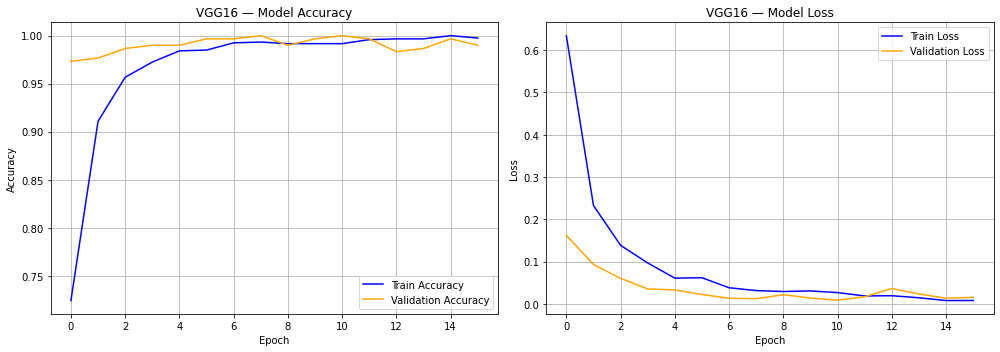

  ✔ Graphs saved.

💾 STEP 7: Saving Final Model...
  ✔ Final model saved  → 'saved_model_vgg16/final_model_vgg16.h5'
  ✔ Best model saved   → 'saved_model_vgg16/best_model_vgg16.h5'
  ✔ Model info saved   → 'saved_model_vgg16/model_info.json'

══════════════════════════════════════════════════
  🎉 VGG16 Training Complete!
  Final Validation Accuracy : 100.00%
══════════════════════════════════════════════════

📊 STEP 8: Final Comparison — All 3 Models...

═════════════════════════════════════════════════════════════════
  Metric                  MobileNetV2     ResNet50        VGG16
  ─────────────────────────────────────────────────────────────
  Val Accuracy                  96.0%       72.33%       100.0%
  Val Loss                     0.0972       0.6165       0.0086
  Epochs Trained                   20           20           16
  Total Params              2,430,403   24,145,539   21,170,755
═════════════════════════════════════════════════════════════════

  🏆 Best Model Overall 

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Training VGG16 Model...\n")

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

CONFIG = {
    "dataset_dir":      "AI_Document_Classifier_Augmented",
    "model_save_dir":   "saved_model_vgg16",
    "image_size":       (224, 224),
    "batch_size":       16,
    "epochs":           20,
    "learning_rate":    0.0001,
    "validation_split": 0.2,
    "classes":          ["Aadhar_Card", "Pan_Card", "Marksheet"],
    "seed":             42,
}

Path(CONFIG["model_save_dir"]).mkdir(parents=True, exist_ok=True)

print("═" * 50)
print("  AI Document Classifier — VGG16 Training")
print("  Framework : TensorFlow/Keras")
print("  Model     : VGG16 (Transfer Learning)")
print("  Device    : CPU")
print("═" * 50)


# ─────────────────────────────────────────────
# STEP 1 — DATA PREPARATION
# ─────────────────────────────────────────────

print("\n📂 STEP 1: Loading Dataset...")

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=CONFIG["validation_split"],
)

train_generator = train_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="training",
    seed=CONFIG["seed"],
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    CONFIG["dataset_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    subset="validation",
    seed=CONFIG["seed"],
    shuffle=False,
)

class_indices = train_generator.class_indices
class_names   = {v: k for k, v in class_indices.items()}

print(f"\n  Classes found     : {class_indices}")
print(f"  Training images   : {train_generator.samples}")
print(f"  Validation images : {val_generator.samples}")

with open(f"{CONFIG['model_save_dir']}/class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=2)
print(f"  ✔ Class mapping saved.")


# ─────────────────────────────────────────────
# STEP 2 — BUILD VGG16 MODEL
# ─────────────────────────────────────────────

print("\n🧠 STEP 2: Building VGG16 Model...")

base_model = VGG16(
    input_shape=(*CONFIG["image_size"], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

x      = base_model.output
x      = Flatten()(x)
x      = Dense(256, activation="relu")(x)
x      = Dropout(0.5)(x)
x      = Dense(128, activation="relu")(x)
x      = Dropout(0.3)(x)
output = Dense(len(CONFIG["classes"]), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=CONFIG["learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"  Total layers     : {len(model.layers)}")
print(f"  Trainable layers : {len([l for l in model.layers if l.trainable])}")
print(f"  Frozen layers    : {len([l for l in model.layers if not l.trainable])}")


# ─────────────────────────────────────────────
# STEP 3 — CALLBACKS
# ─────────────────────────────────────────────

print("\n⚙️  STEP 3: Setting up Callbacks...")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=f"{CONFIG['model_save_dir']}/best_model_vgg16.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("  ✔ EarlyStopping     — stops if no improvement for 5 epochs")
print("  ✔ ModelCheckpoint   — saves best model automatically")
print("  ✔ ReduceLROnPlateau — reduces learning rate when stuck")


# ─────────────────────────────────────────────
# STEP 4 — TRAIN MODEL
# ─────────────────────────────────────────────

print("\n🚀 STEP 4: Training Started...")
print("  VGG16 is heavier than MobileNetV2.")
print("  This may take 40–60 mins on CPU. Please wait...\n")

history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1,
)

print("\n  ✔ Training Complete!")


# ─────────────────────────────────────────────
# STEP 5 — EVALUATE MODEL
# ─────────────────────────────────────────────

print("\n📊 STEP 5: Evaluating Model...")

val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"\n  Validation Loss     : {val_loss:.4f}")
print(f"  Validation Accuracy : {val_accuracy * 100:.2f}%")


# ─────────────────────────────────────────────
# STEP 6 — PLOT TRAINING GRAPHS
# ─────────────────────────────────────────────

print("\n📈 STEP 6: Plotting Training Graphs...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[0].set_title("VGG16 — Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[1].set_title("VGG16 — Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['model_save_dir']}/vgg16_training_graphs.png", dpi=150)
plt.show()
print("  ✔ Graphs saved.")


# ─────────────────────────────────────────────
# STEP 7 — SAVE FINAL MODEL
# ─────────────────────────────────────────────

print("\n💾 STEP 7: Saving Final Model...")

model.save(f"{CONFIG['model_save_dir']}/final_model_vgg16.h5")

model_info = {
    "model_name":     "VGG16",
    "input_size":     CONFIG["image_size"],
    "classes":        class_indices,
    "total_params":   model.count_params(),
    "val_accuracy":   round(val_accuracy * 100, 2),
    "val_loss":       round(val_loss, 4),
    "epochs_trained": len(history.history["loss"]),
    "framework":      "TensorFlow/Keras",
}

with open(f"{CONFIG['model_save_dir']}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"  ✔ Final model saved  → 'saved_model_vgg16/final_model_vgg16.h5'")
print(f"  ✔ Best model saved   → 'saved_model_vgg16/best_model_vgg16.h5'")
print(f"  ✔ Model info saved   → 'saved_model_vgg16/model_info.json'")

print("\n" + "═" * 50)
print("  🎉 VGG16 Training Complete!")
print(f"  Final Validation Accuracy : {val_accuracy * 100:.2f}%")
print("═" * 50)


# ─────────────────────────────────────────────
# STEP 8 — FINAL COMPARISON ALL 3 MODELS
# ─────────────────────────────────────────────

print("\n📊 STEP 8: Final Comparison — All 3 Models...")

# Load previous results
with open("saved_model/model_info.json", "r") as f:
    mobilenet_info = json.load(f)

with open("saved_model_resnet/model_info.json", "r") as f:
    resnet_info = json.load(f)

vgg16_accuracy = round(val_accuracy * 100, 2)
vgg16_loss     = round(val_loss, 4)
vgg16_params   = model.count_params()
vgg16_epochs   = len(history.history["loss"])

print("\n" + "═" * 65)
print(f"  {'Metric':<22} {'MobileNetV2':>12} {'ResNet50':>12} {'VGG16':>12}")
print("  " + "─" * 61)
print(f"  {'Val Accuracy':<22} {str(mobilenet_info['val_accuracy'])+'%':>12} {str(resnet_info['val_accuracy'])+'%':>12} {str(vgg16_accuracy)+'%':>12}")
print(f"  {'Val Loss':<22} {mobilenet_info['val_loss']:>12} {resnet_info['val_loss']:>12} {vgg16_loss:>12}")
print(f"  {'Epochs Trained':<22} {mobilenet_info['epochs_trained']:>12} {resnet_info['epochs_trained']:>12} {vgg16_epochs:>12}")
print(f"  {'Total Params':<22} {mobilenet_info['total_params']:>12,} {resnet_info['total_params']:>12,} {vgg16_params:>12,}")
print("═" * 65)

# Pick overall winner
all_models = {
    "MobileNetV2": mobilenet_info["val_accuracy"],
    "ResNet50":    resnet_info["val_accuracy"],
    "VGG16":       vgg16_accuracy,
}
winner = max(all_models, key=all_models.get)

print(f"\n  🏆 Best Model Overall : {winner} ({all_models[winner]}%)")
print(f"  ✅ Recommended for FastAPI Backend : {winner}")
print("\n" + "═" * 65)

Loading model...
✔ Model loaded successfully!
✔ Classes : {0: 'Aadhar_Card', 1: 'Marksheet', 2: 'Pan_Card'}

Testing image: aadhar_card.jpg
────────────────────────────────────────


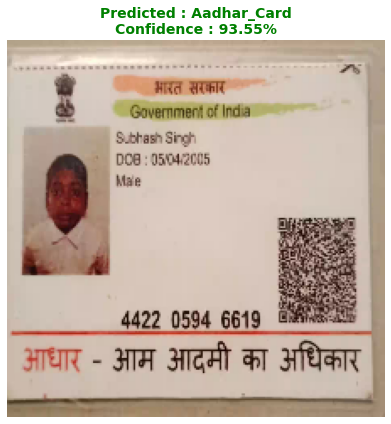


  🏆 Predicted Class : Aadhar_Card
  📊 Confidence      : 93.55%

  All Probabilities:
    Aadhar_Card           93.55%  ██████████████████
    Pan_Card               6.35%  █
    Marksheet              0.10%  
────────────────────────────────────────


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ─────────────────────────────────────────────
# STEP 1 — LOAD MODEL & CLASS INDICES
# ─────────────────────────────────────────────

print("Loading model...")
model = load_model("saved_model/best_model.h5")

with open("saved_model/class_indices.json", "r") as f:
    class_indices = json.load(f)

# Flip: {0: 'Aadhar_Card', 1: 'Marksheet', 2: 'Pan_Card'}
class_names = {v: k for k, v in class_indices.items()}
print(f"✔ Model loaded successfully!")
print(f"✔ Classes : {class_names}\n")


# ─────────────────────────────────────────────
# STEP 2 — PREDICTION FUNCTION
# ─────────────────────────────────────────────

def predict_document(img_path):
    """
    Predict document type from image path.
    Works with any image downloaded from Google.
    """
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0                        # rescale
    img_array = np.expand_dims(img_array, axis=0)        # add batch dimension

    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    # All class probabilities
    all_probs = {class_names[i]: round(float(predictions[0][i]) * 100, 2)
                 for i in range(len(class_names))}

    return predicted_class, confidence, all_probs


# ─────────────────────────────────────────────
# STEP 3 — TEST WITH YOUR IMAGE
# ─────────────────────────────────────────────

def test_image(img_path):
    """Test and display result for a single image."""
    img_path = Path(img_path)

    if not img_path.exists():
        print(f"❌ Image not found: {img_path}")
        print(f"   Make sure the image is in: {Path.cwd()}")
        return

    print(f"Testing image: {img_path.name}")
    print("─" * 40)

    # Predict
    predicted_class, confidence, all_probs = predict_document(img_path)

    # Display image with result
    img_display = image.load_img(img_path, target_size=(224, 224))

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.axis("off")

    # Color title green if high confidence, red if low
    color = "green" if confidence >= 80 else "red"
    plt.title(
        f"Predicted : {predicted_class}\nConfidence : {confidence:.2f}%",
        fontsize=14, color=color, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # Print all probabilities
    print(f"\n  🏆 Predicted Class : {predicted_class}")
    print(f"  📊 Confidence      : {confidence:.2f}%")
    print(f"\n  All Probabilities:")
    for cls, prob in sorted(all_probs.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(prob / 5)
        print(f"    {cls:<20} {prob:>6.2f}%  {bar}")
    print("─" * 40)


# ─────────────────────────────────────────────
# STEP 4 — RUN TEST
# ─────────────────────────────────────────────

# 👇 CHANGE THIS to your downloaded image filename
test_image("aadhar_card.jpg")